In [31]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [2]:
train_path = r"C:\Users\Rudra\Desktop\kaggle\university-query-priority\university_query_train.csv"
test_path = r"C:\Users\Rudra\Desktop\kaggle\university-query-priority\university_query_test.csv"

- Data: https://www.kaggle.com/datasets/coderanand/university-query-priority-classification

> For this dataset let's deep and create a series of notebook for each concept.
>
> Ex: https://www.kaggle.com/code/rudraprasadbhuyan/fake-real-news-bert-pretrained-model

In [3]:
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Query_ID          5000 non-null   int64 
 1   Student_Query     5000 non-null   object
 2   Department        5000 non-null   object
 3   Days_To_Deadline  5000 non-null   int64 
 4   Priority_Label    5000 non-null   object
dtypes: int64(2), object(3)
memory usage: 195.4+ KB


In [5]:
train_df = train_df.drop(columns=["Query_ID"])

In [6]:
train_df.sample(3)

,Student_Query,Department,Days_To_Deadline,Priority_Label
1705,Fee payment deadline is today but portal is no...,Administration,28,High
2897,I need a bonafide certificate.,Hostel Office,1,Medium
3483,How to reset my university portal password?,Hostel Office,41,Medium


In [30]:
train_df.groupby("Department")["Days_To_Deadline"] \
    .mean().reset_index()

,Department,Days_To_Deadline
0,Academic Office,30.483146
1,Administration,30.517711
2,Examination Cell,30.644156
3,Finance Office,29.951807
4,Hostel Office,30.341689
5,IT Support,30.625000
6,Library,31.706687


In [28]:
train_df.groupby("Department")["Priority_Label"] \
    .value_counts().reset_index() \
    .pivot_table(
        index="Department",
        columns="Priority_Label",
        values="count",
        fill_value=0
    )

Priority_Label,High,Low,Medium
Department,,,
Academic Office,243.0,241.0,228.0
Administration,262.0,252.0,220.0
Examination Cell,251.0,259.0,260.0
Finance Office,224.0,230.0,210.0
Hostel Office,271.0,244.0,243.0
IT Support,247.0,232.0,225.0
Library,205.0,234.0,219.0


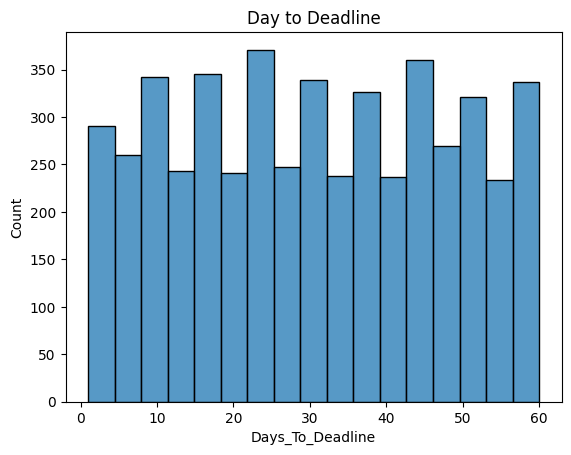

In [ ]:

sns.histplot(
    train_df["Days_To_Deadline"]
)
plt.title("Day to Deadline")
plt.show()

- Histogram is mostly looks like uniform

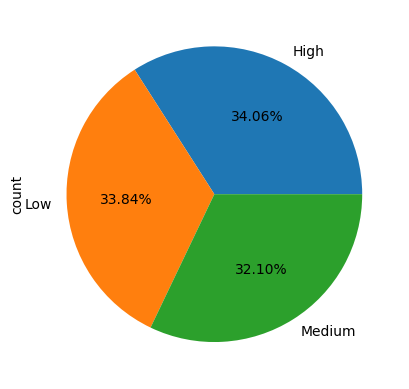

In [ ]:
train_df["Priority_Label"].value_counts().plot.pie(autopct="%2.2f%%")
plt.show()

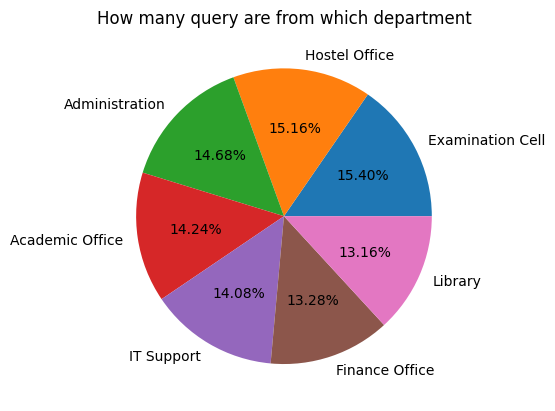

In [36]:
train_df["Department"].value_counts().plot.pie(autopct="%2.2f%%")
plt.title("How many query are from which department")
plt.axis("off")
plt.show()

In [34]:
train_df[train_df["Student_Query"].duplicated()]

,Student_Query,Department,Days_To_Deadline,Priority_Label
5,How to reset my university portal password?,IT Support,5,Medium
11,Please share syllabus for Data Science course.,Library,48,Low
14,My admit card has incorrect details.,Academic Office,3,High
16,LMS is not allowing assignment upload.,Hostel Office,35,Medium
17,What are university working hours?,Finance Office,16,Low
...,...,...,...,...
4995,What are university working hours?,Academic Office,21,Low
4996,Fee payment deadline is today but portal is no...,Hostel Office,44,High
4997,What are university working hours?,Library,24,Low
4998,How to reset my university portal password?,IT Support,27,Medium


In [38]:
text = " ".join(train_df["Student_Query"])
text

"How to join student clubs? My admit card has incorrect details. How to reset my university portal password? My exam form is not submitted and tomorrow is the last date. I cannot download my hall ticket for tomorrow's exam. How to reset my university portal password? Please share syllabus for Data Science course. Request for internship approval letter. LMS is not allowing assignment upload. When will the library issue new ID cards? What is the hostel application procedure? Please share syllabus for Data Science course. What are university working hours? I want to change my elective subject. My admit card has incorrect details. I have not received my scholarship amount. LMS is not allowing assignment upload. What are university working hours? I want to change my elective subject. When will the library issue new ID cards? How to join student clubs? Please share syllabus for Data Science course. How to reset my university portal password? What is the hostel application procedure? Please s

In [45]:
word_cloud = WordCloud(
    height=1000,
    width=1800,
    background_color="white",
    max_words=2500,
    min_word_length=3
).generate(text)

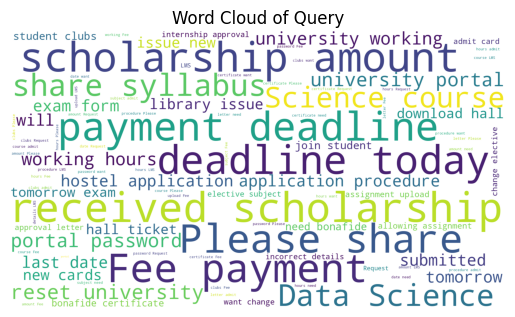

In [46]:
plt.imshow(word_cloud)
plt.title("Word Cloud of Query")
plt.axis("off")
plt.show()

- V1: 23-02-2026 | 20:53 IST